# Estimation of R
Rを求めて海表面情報を探索する試み。

In [1]:
# 依存パッケージをimport

import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pywt

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.gnssir_cl import gnssir

#@formatter:off
%matplotlib inline

## RINEX → SNR

下記ディレクトリにRINEXファイルを入れる。

refl_code/yyyy/rinex/TTTT/TTTTXXX0.yyo
- yyyy：西暦
- TTTT：局名。アルファベット4文字。
- XXX：day of year
- yy：西暦下二桁

In [2]:
year = 2020
doy = 277
doy_end = 288
station = "calc"

rinex2snr(station, year, doy, doy_end=doy_end, nolook=True)

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr value of  66
Using default orbit for this time period:  nav
Using archive value of  all
Station  calc  has four characters, assume RINEX 2.11 format
No parallel processing
SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr66 

SNR file already e

## SNRファイルの読み込み

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# SNR ファイルのカラム名（マニュアル準拠）
SNR_COLUMNS_FULL = [
    "sat",              # 衛星番号
    "elev_deg",         # 仰角 [deg]
    "az_deg",           # 方位角 [deg]
    "sec_of_day",       # 秒（GPS time）
    "edot_deg_per_s",   # 仰角変化率 [deg/s]
    "snr_L6",           # S6 (L6) SNR [dB-Hz]
    "snr_L1",           # S1 (L1)
    "snr_L2",           # S2 (L2)
    "snr_L5",           # S5 (L5)
    "snr_L7",           # S7 (L7)
    "snr_L8",           # S8 (L8)
]


def read_snr_file_gz(path: Path) -> pd.DataFrame:
    """1つの .snr*.gz ファイルを読み込んで DataFrame を返す。"""
    df = pd.read_csv(
        path,
        sep=r"\s+",        # ← FutureWarning 回避
        header=None,
        comment="#",
        compression="gzip",
        engine="python",
    )
    n_cols = df.shape[1]
    df.columns = SNR_COLUMNS_FULL[:n_cols]
    return df


def load_snr_directory(year: int, station: str,
                       base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    /etc/gnssrefl/refl_code/{year}/snr/{station}/ 配下の
    .snr*.gz ファイルだけを全部読み込んで

    - snr_dict: {ファイル名: DataFrame}
    - snr_table: 全ファイルを縦結合した DataFrame
                 (year, station, doy, file などの情報付き)

    を返す。
    """
    snr_dir = Path(base_dir) / str(year) / "snr" / station

    if not snr_dir.is_dir():
        raise FileNotFoundError(f"ディレクトリが見つかりません: {snr_dir}")

    snr_files = sorted(snr_dir.glob("*.snr*.gz"))

    if not snr_files:
        print(f"*.snr*.gz が見つかりません: {snr_dir}")

    snr_dict = {}
    table_list = []

    for f in snr_files:
        df = read_snr_file_gz(f)
        snr_dict[f.name] = df

        # ファイル名から DOY を推定（例: calc2770.20.snr66.gz）
        name_no_gz = f.name[:-3] if f.name.endswith(".snr88.gz") else f.name
        stem = name_no_gz.split(".")[0]   # "calc2770"
        doy = int(stem[len(station):len(station) + 3])  # "277"

        df2 = df.copy()
        df2["year"] = year
        df2["station"] = station
        df2["file"] = f.name
        df2["doy"] = doy
        table_list.append(df2)

    if table_list:
        snr_table = pd.concat(table_list, ignore_index=True)
    else:
        snr_table = pd.DataFrame()

    return snr_dict, snr_table

def main(year: int,
         station: str,
         snr_dict_existing=None,
         base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    - Jupyter で既に snr_dict を作っているなら snr_dict_existing を渡す
    - そうでなければディレクトリから読み込む

    戻り値:
        snr_dict, snr_table
    """
    if snr_dict_existing is None:
        snr_dict, snr_table = load_snr_directory(year, station, base_dir=base_dir)
    else:
        # 既存の snr_dict から snr_table だけ再構成したい場合など
        snr_dict = snr_dict_existing
        # ここで snr_table を組み立て直すなら、上の build 処理を使い回すイメージ
        # 必要なら別関数に分けてもよい
        rows = []
        for fname, df in snr_dict.items():
            name_no_gz = fname[:-3] if fname.endswith(".gz") else fname
            stem = name_no_gz.split(".")[0]
            doy = int(stem[len(station):len(station) + 3])

            tmp = df.copy()
            tmp["year"] = year
            tmp["station"] = station
            tmp["file"] = fname
            tmp["doy"] = doy
            rows.append(tmp)
        snr_table = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    return snr_dict, snr_table


## コヒーレント・インコヒーレント比率を求める

### Plot用

In [4]:
import matplotlib.pyplot as plt

def compute_prominence_from_bgmodel_res(res, h_grid, h0, eps=1e-18):
    """
    Π(e) = P_peak_excess / P_bg_in
      P_peak_excess = res["P_coh"]   (window-integrated excess)
      P_bg_in       = B0(e) * sum_h w_coh(h)
    """
    sigma = float(res["sigma_coh"])
    w = np.exp(-(h_grid - h0)**2 / (2.0 * sigma**2))
    w = np.clip(w, 0.0, 1.0)
    wsum = float(np.sum(w))

    P_peak = np.asarray(res["P_coh"], float)   # excess, already window-integrated
    B0 = np.asarray(res["B0"], float)          # floor per-h-bin
    P_bg_in = B0 * wsum

    Pi = P_peak / (P_bg_in + eps)
    return Pi, P_peak, P_bg_in, wsum


def plot_prominence_for_track(e_deg, Pi, sat, dir_val, doy, signal,
                              e_lim=None, y_lim=None, show=True):
    e_deg = np.asarray(e_deg, float)
    Pi = np.asarray(Pi, float)

    fig, ax = plt.subplots(figsize=(7.8, 3.8))
    ax.plot(e_deg, Pi, lw=1.6)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel("Prominence Π(e) = P_peak_excess / P_bg_in  (log)")
    ax.set_title(f"Prominence Π(e)  sat={sat} ({dir_val})  {signal}  doy={doy}")

    if e_lim is not None:
        ax.set_xlim(*e_lim)
    if y_lim is not None:
        ax.set_ylim(*y_lim)

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

def plot_R_e(e: np.ndarray, R: np.ndarray, title: str | None = None):
    plt.figure()
    plt.plot(e, R)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    plt.figure()
    R_dB = 10 * np.log10(R)
    plt.plot(e, R_dB)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh [dB]")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    


def plot_wavelet_power_e_h(e_grid, h_grid, P, title=None):
    import numpy as np
    import matplotlib.pyplot as plt

    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P, float)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(
            f"P.shape={P.shape}, expected ({len(e_grid)}, {len(h_grid)})"
        )

    # 0 以上に限定
    P[P < 0] = 0.0
    Pmax = np.nanmax(P)
    if not np.isfinite(Pmax) or Pmax <= 0:
        Pmax = 1.0  # 全部ゼロだったときの保険

    E, H = np.meshgrid(e_grid, h_grid, indexing="xy")

    plt.figure()
    pcm = plt.pcolormesh(E, H, P.T, shading="auto", vmin=0.0, vmax=Pmax)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("Height h [m]")
    if title is not None:
        plt.title(title)
    cb = plt.colorbar(pcm)
    cb.set_label(r"$|W(e,h)|^2$")
    plt.tight_layout()
    plt.show()



読み込み完了: 497108 rows


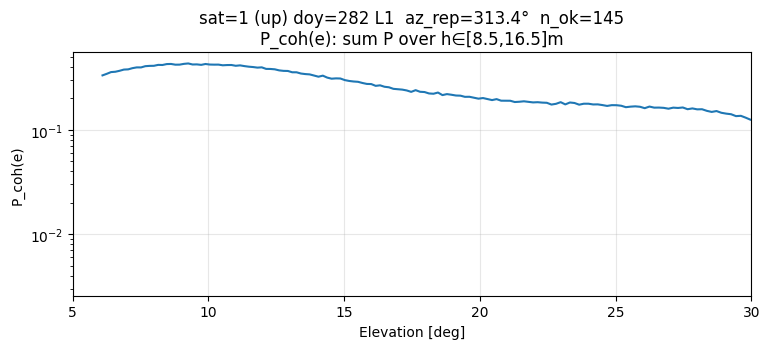

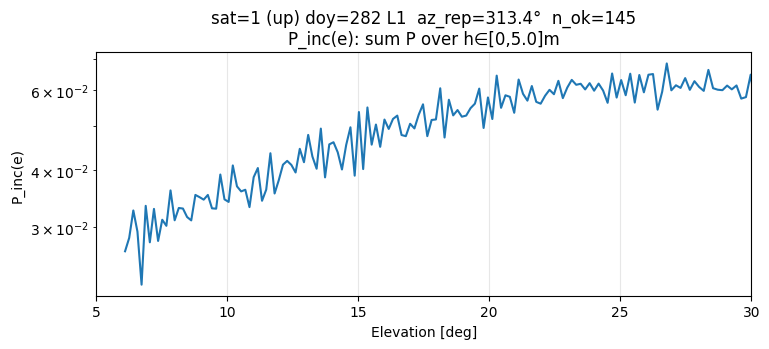

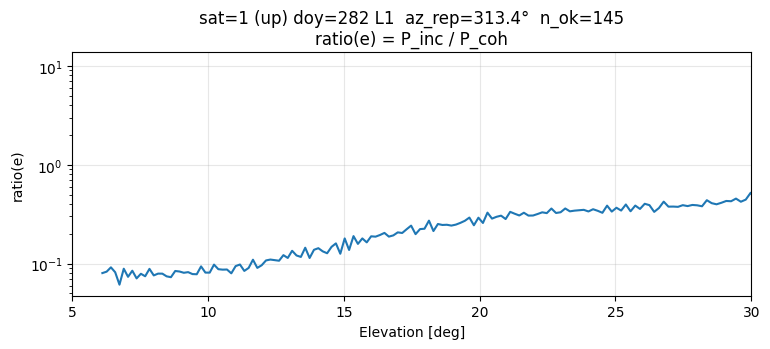

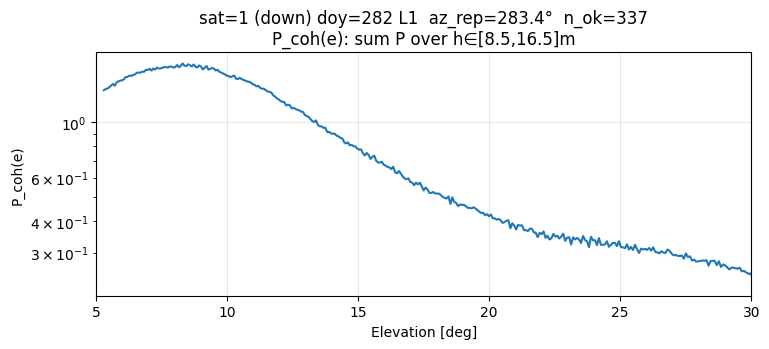

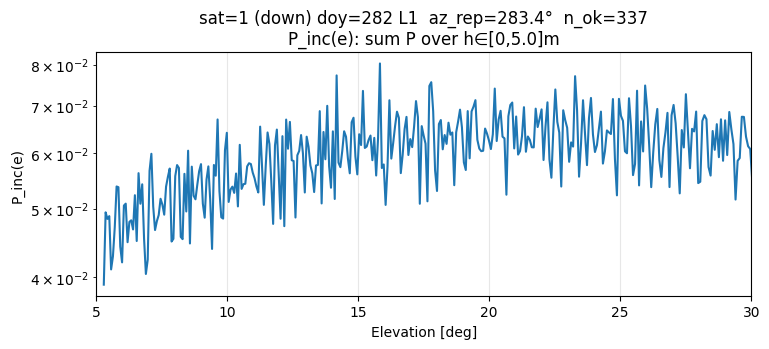

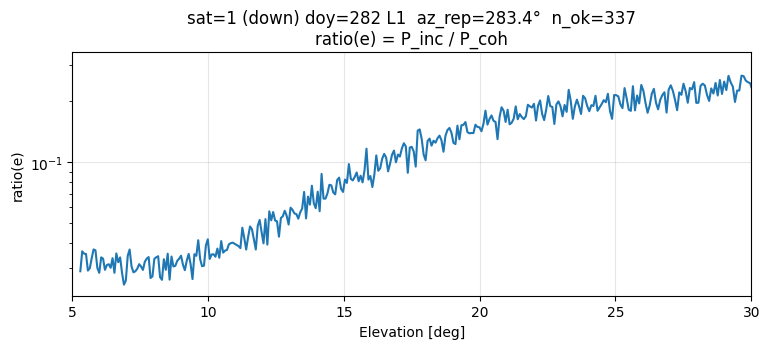

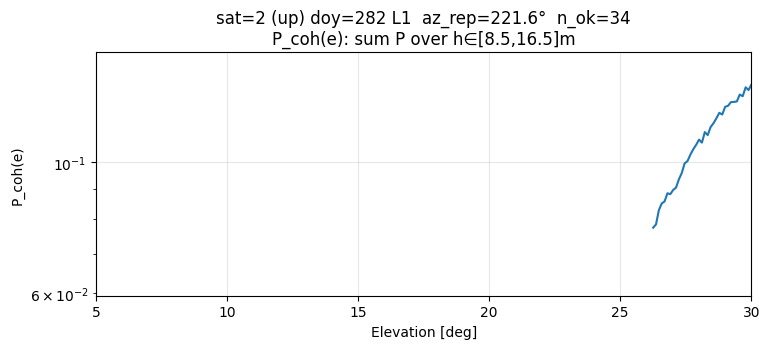

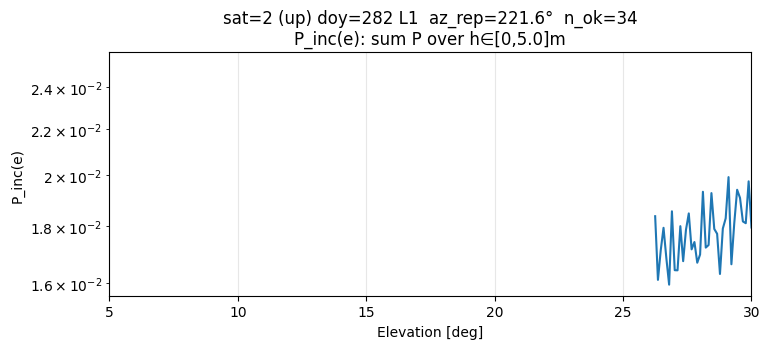

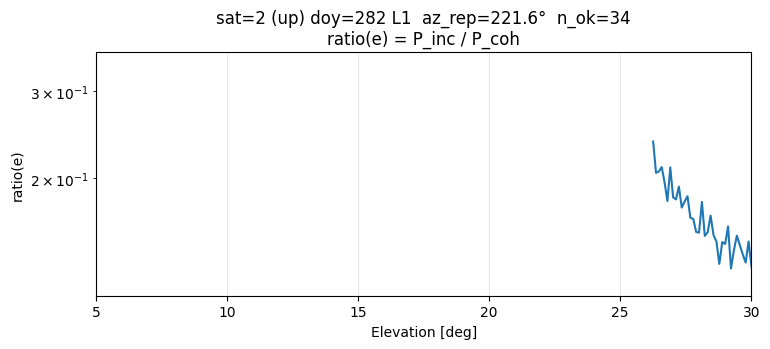

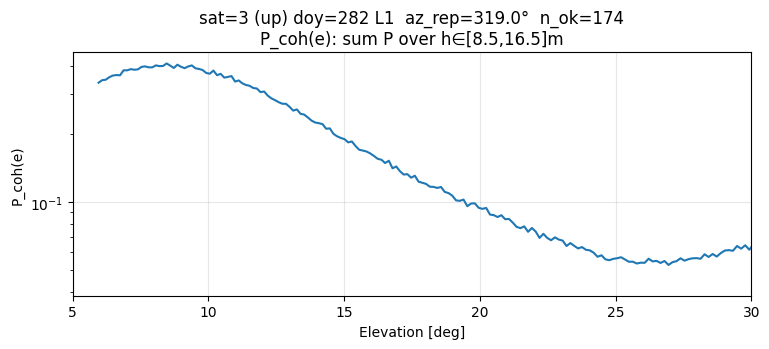

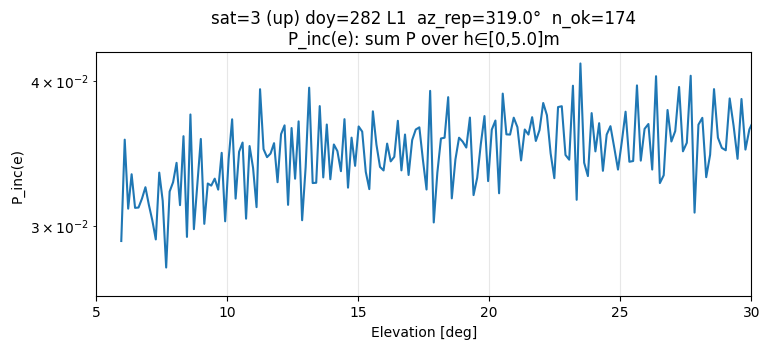

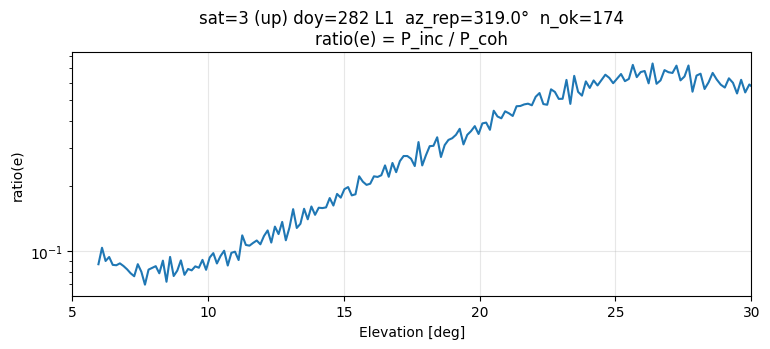

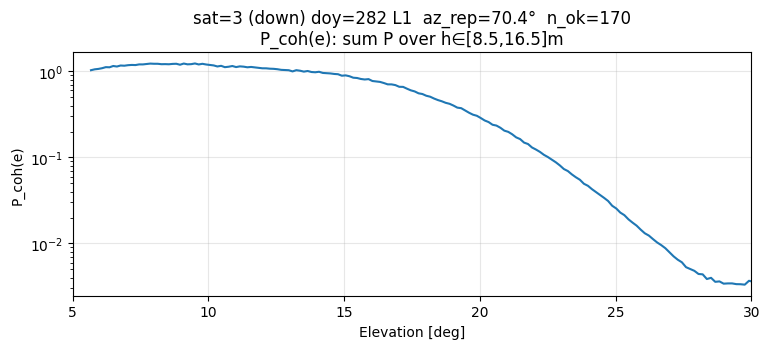

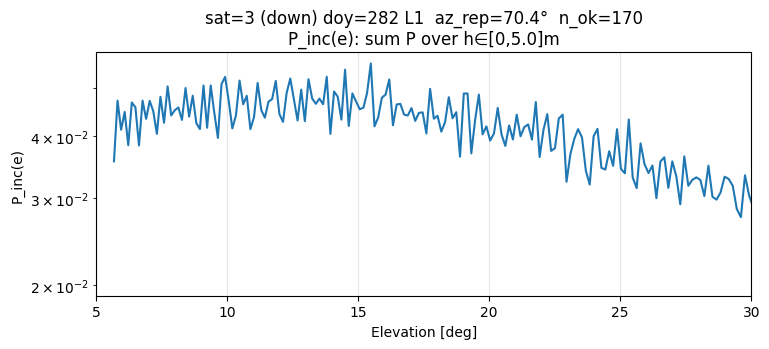

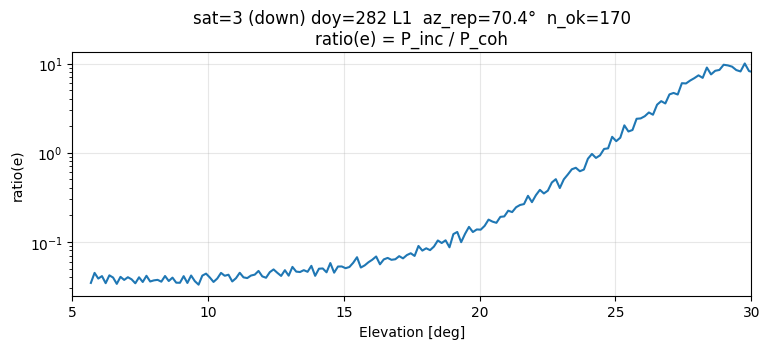

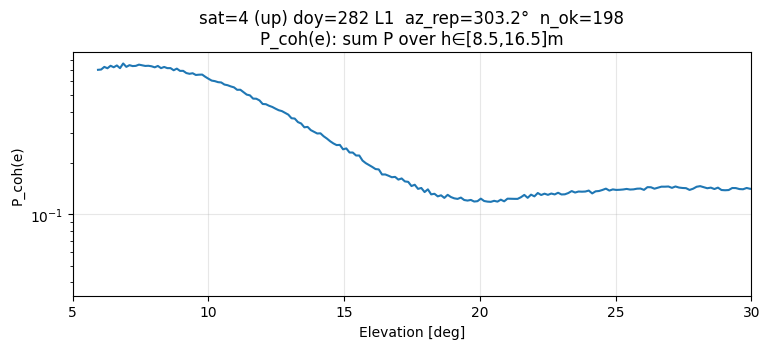

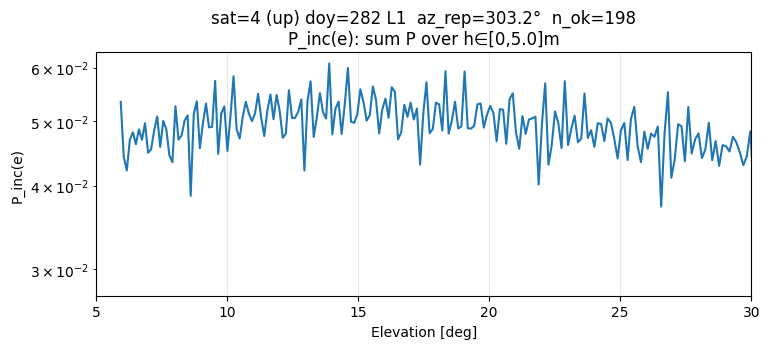

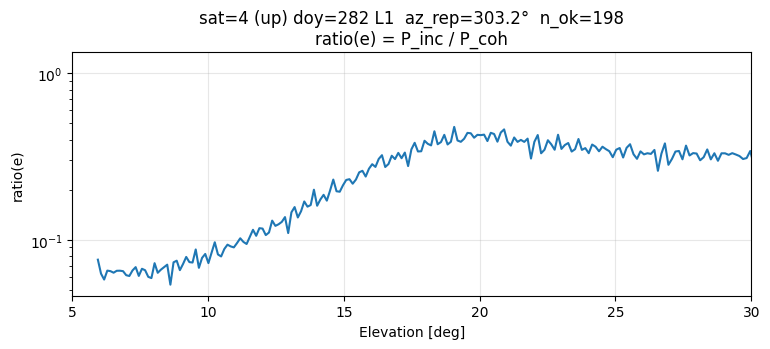

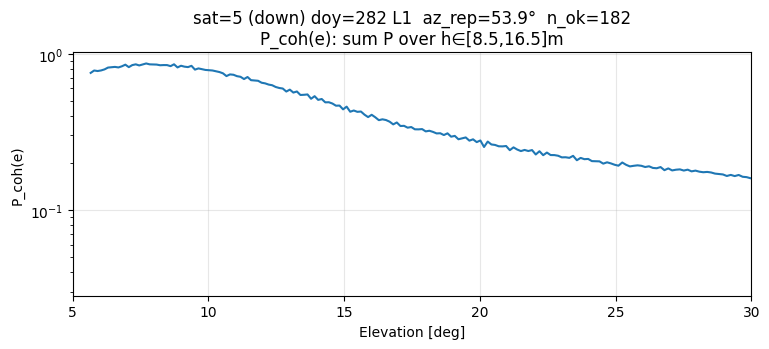

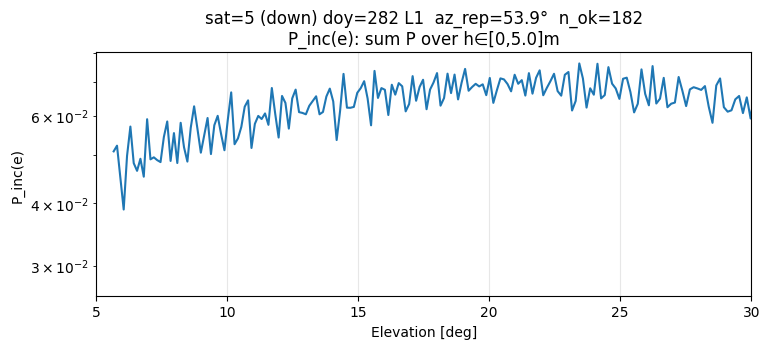

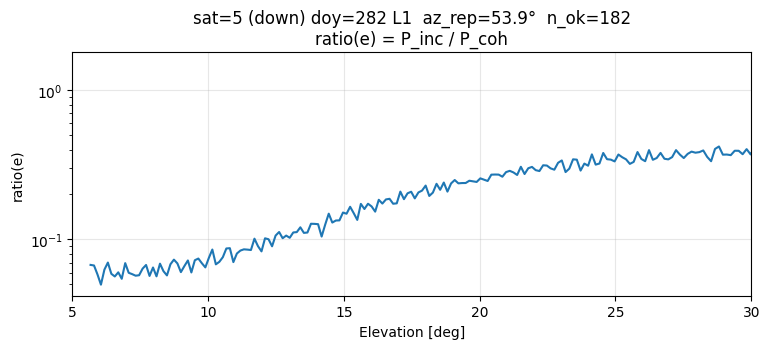

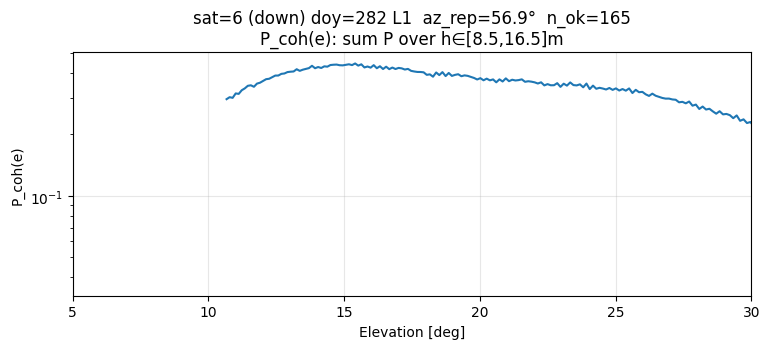

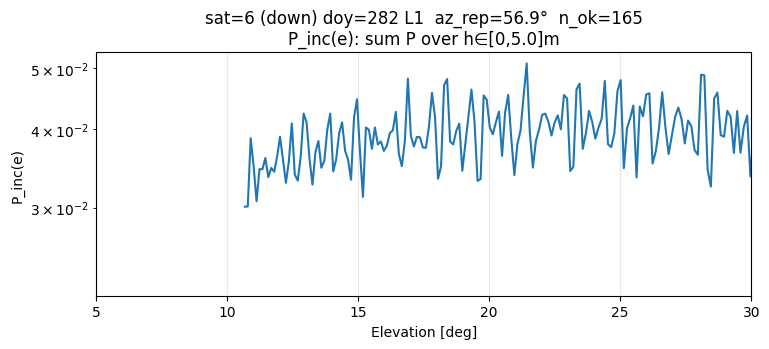

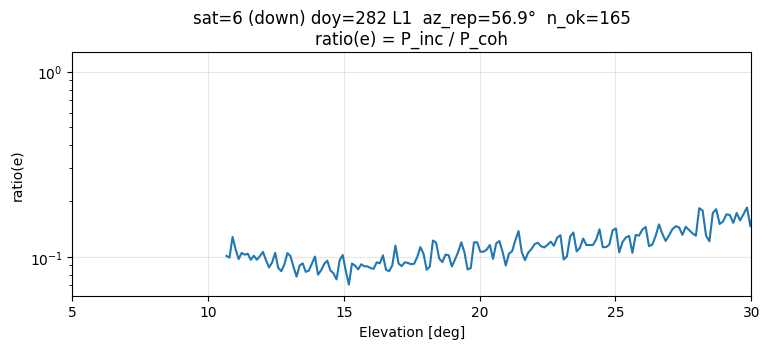

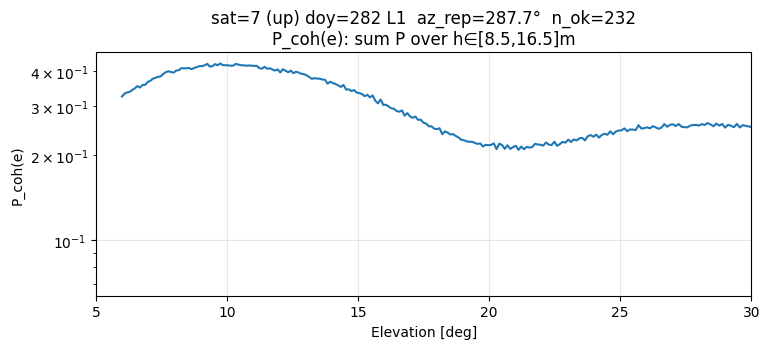

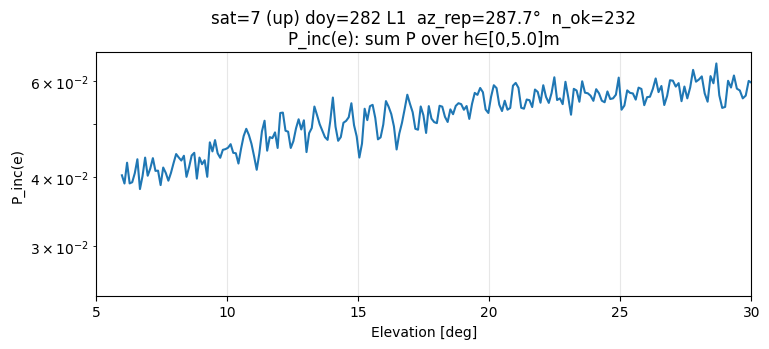

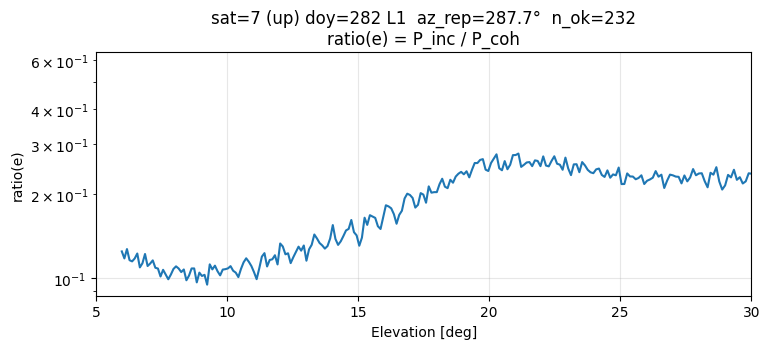

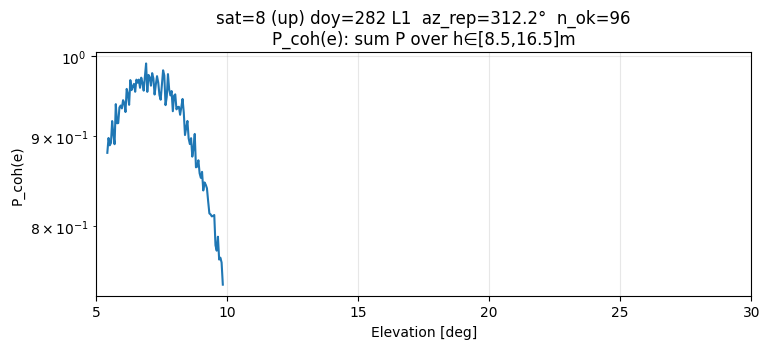

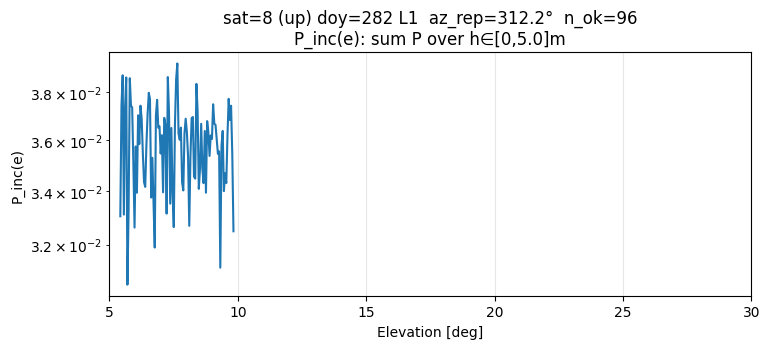

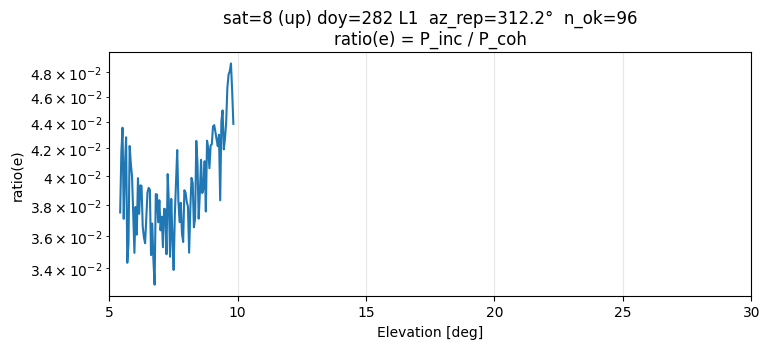

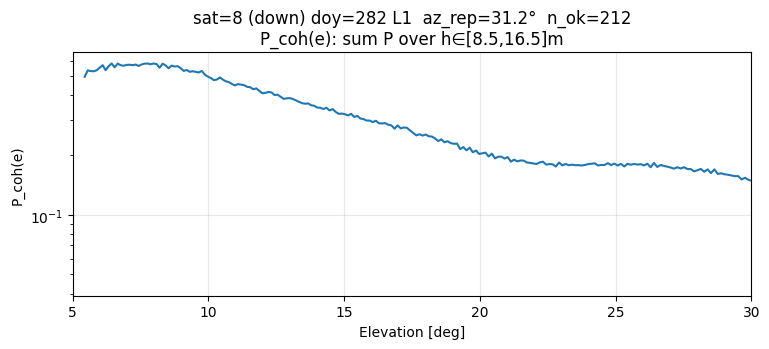

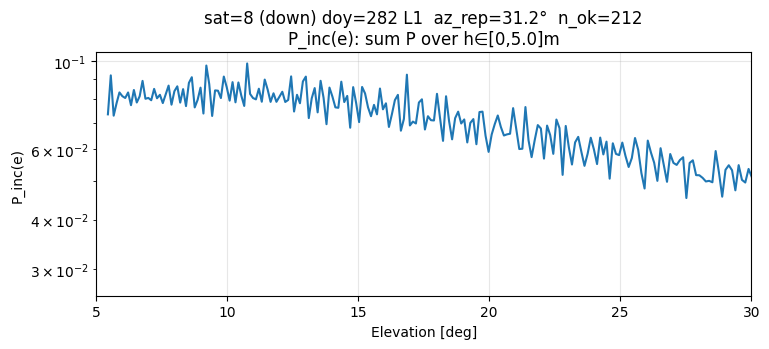

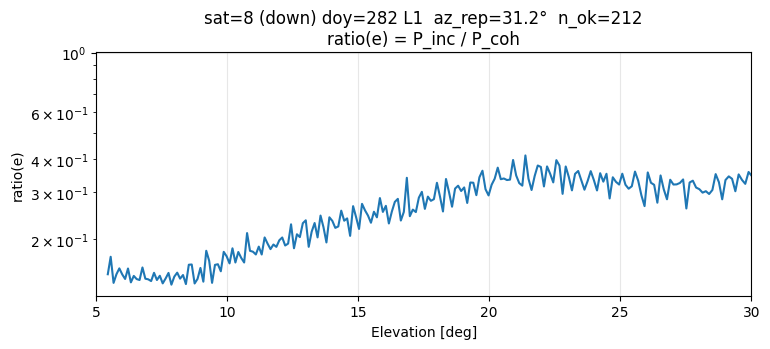

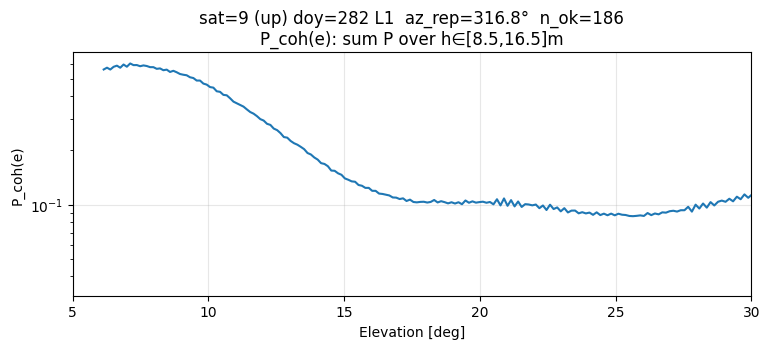

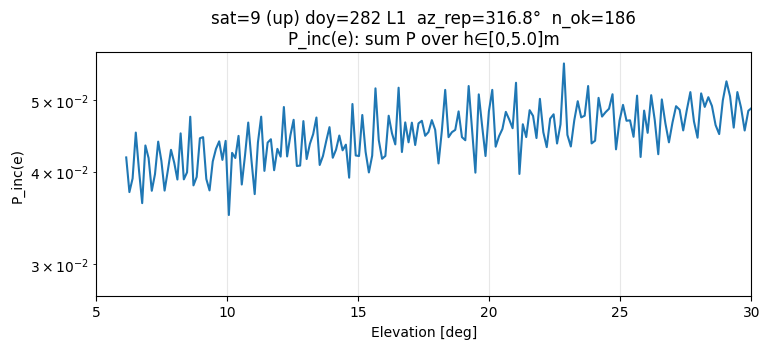

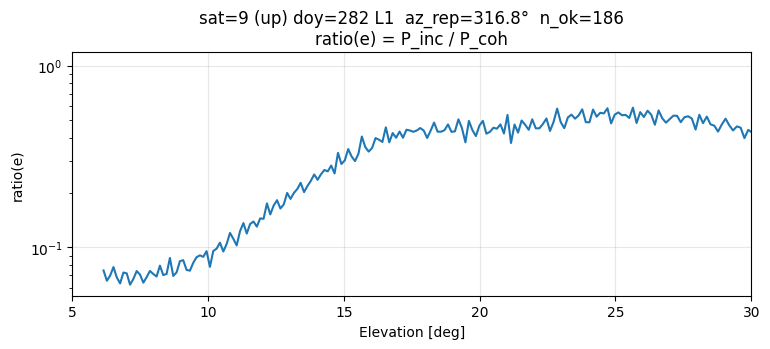

drop_stat: {'no_data': 1, 'short': 4, 'wavelet_fail': 0, 'too_few_valid': 10}
    sat direction  az_rep_deg  Pcoh_rep_median  Pinc_rep_median  \
0     1      down  283.394308         0.572210         0.060335   
1     3      down   70.444073         0.615292         0.042911   
2     5      down   53.865124         0.337773         0.064727   
3     6      down   56.877338         0.364318         0.039092   
4     8      down   31.199459         0.272305         0.072639   
5     9      down   76.826153         0.003461         0.047602   
6    11      down  346.719545         0.367101         0.054140   
7    12      down   72.109203         0.048756         0.034982   
8    13      down  301.743587         0.476486         0.052037   
9    15      down   48.257677         0.335636         0.033786   
10   16      down   48.530608         0.422053         0.054163   
11   21      down   47.241786         0.541147         0.058160   
12   22      down   81.030617         0.064013     

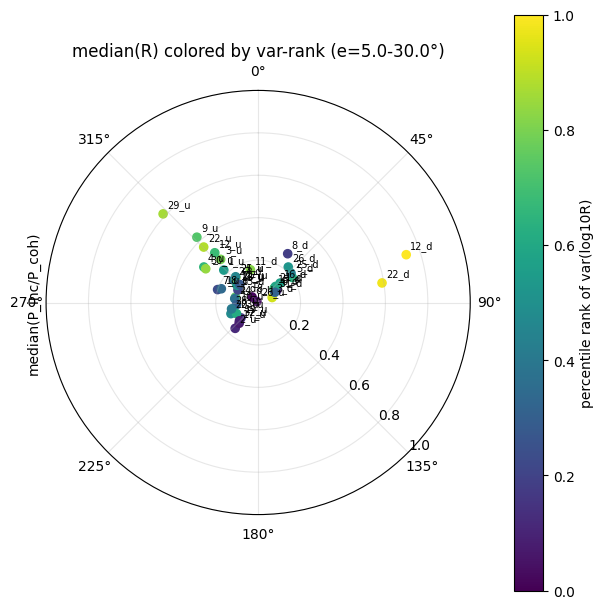

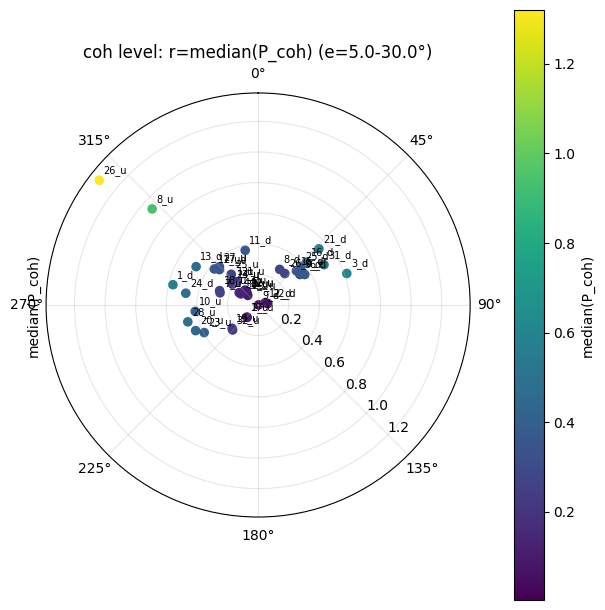

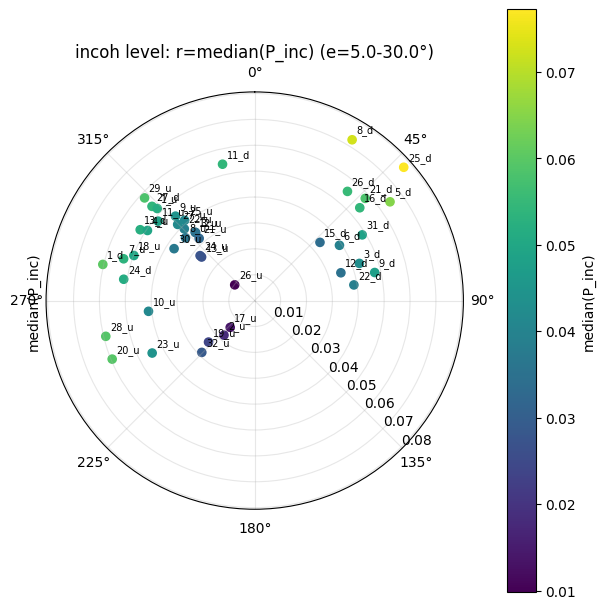

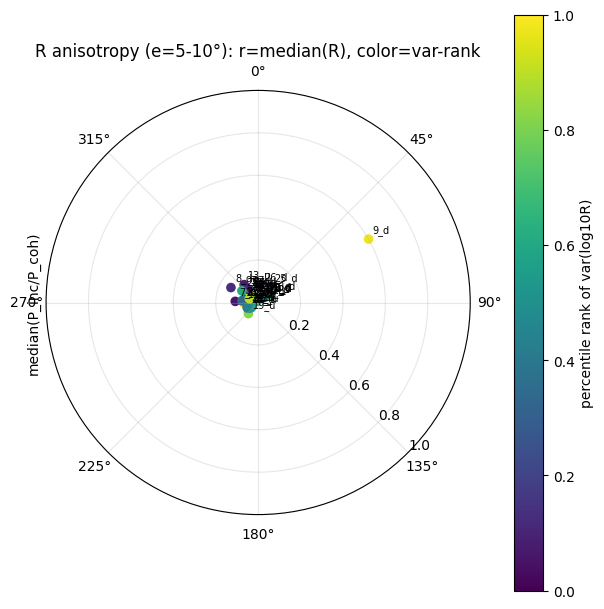

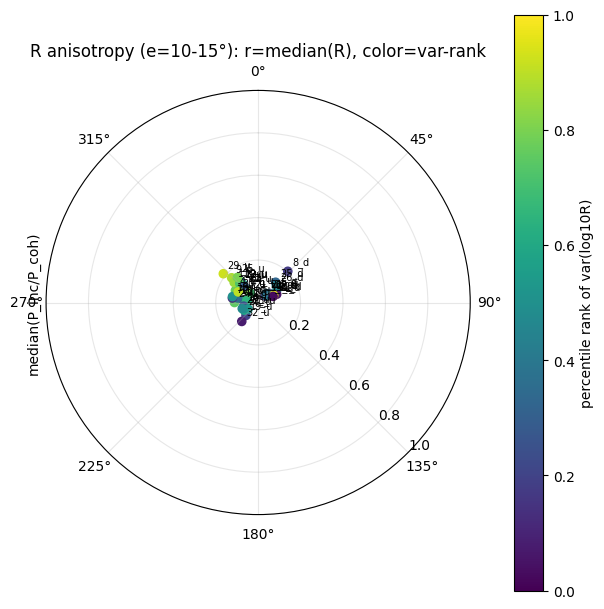

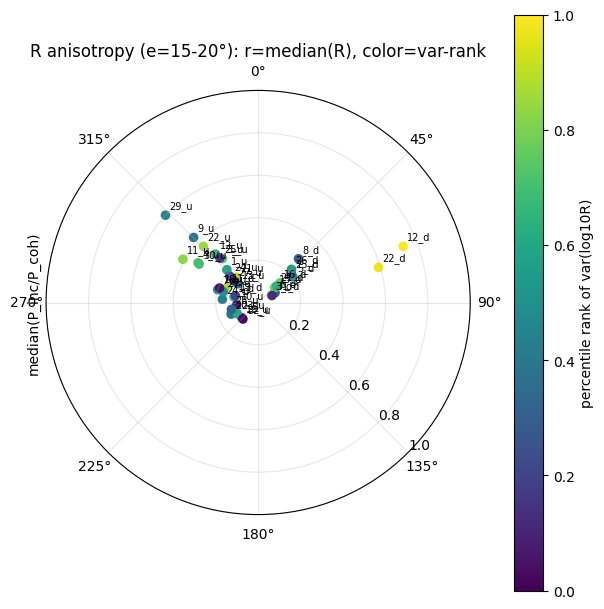

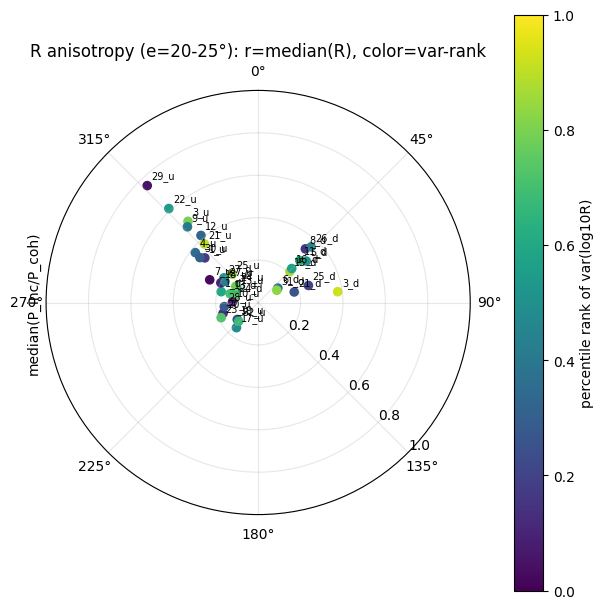

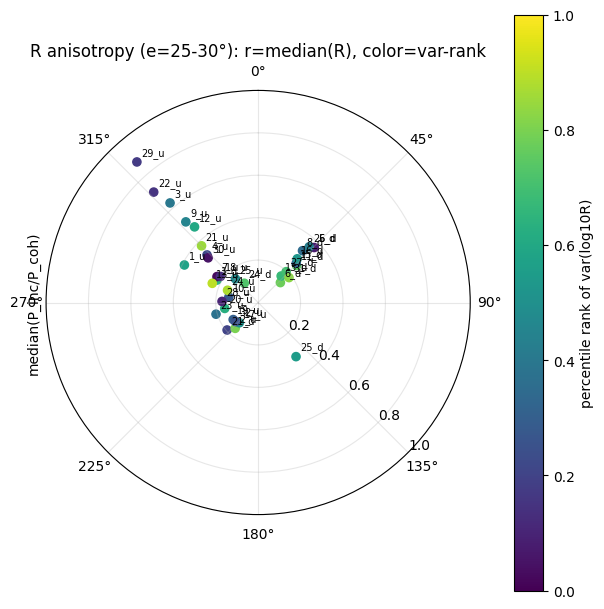

In [58]:
from __future__ import annotations

from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# =========================================================
# Config
# =========================================================

@dataclass(frozen=True)
class RunConfig:
    year: int = 2020
    station: str = "calc"
    doy: int = 282
    signal: str = "L1"
    az_range: tuple[float, float] = (220, 70)

    h0: float = 12.5
    h_grid: np.ndarray = np.linspace(0.5, 20.0, 196)
    N_EDGE_TRIM: int = 5

    # band power params
    COH_HALF_WIDTH: float = 4.0
    INC_H_MAX: float = 5.0

    # per-track time-series plots use this e-range (deg)
    E_MIN: float = 5.0
    E_MAX: float = 30.0
    MIN_POINTS: int = 10

    # band polar (deg)
    E_BANDS: tuple[tuple[float, float], ...] = ((5,10),(10,15),(15,20),(20,25),(25,30))
    MIN_POINTS_BAND: int = 6

    # choose which bands to integrate (deg)
    INTEGRATE_BANDS: tuple[tuple[float, float], ...] = ((15,20),(20,25),(25,30))

    MAX_PLOTS: int = 12


# =========================================================
# Basic utilities
# =========================================================

SIGNAL_COL_MAP = {
    "L1": "snr_L1",
    "L2": "snr_L2",
    "L5": "snr_L5",
    "L6": "snr_L6",
    "L7": "snr_L7",
    "L8": "snr_L8",
}

def normalize_angle_deg(angle: float) -> float:
    return float(np.mod(angle, 360.0))

def azimuth_in_range(az_deg: np.ndarray, az_min: float, az_max: float) -> np.ndarray:
    az = np.mod(np.asarray(az_deg, float), 360.0)
    amin = normalize_angle_deg(az_min)
    amax = normalize_angle_deg(az_max)
    if amin <= amax:
        return (az >= amin) & (az <= amax)
    else:
        return (az >= amin) | (az <= amax)

def add_direction_by_elev(df: pd.DataFrame, eps: float = 1e-3) -> pd.DataFrame:
    if df.empty:
        return df.assign(direction_flag=pd.Series(dtype=str))
    d = df.sort_values("sec_of_day").copy()
    de = d["elev_deg"].diff().to_numpy()
    if len(de) >= 2 and np.isnan(de[0]):
        de[0] = de[1]
    de = np.nan_to_num(de, nan=0.0)
    d["direction_flag"] = np.where(de > eps, "up", np.where(de < -eps, "down", "flat"))
    return d

def select_observations(
    snr_table: pd.DataFrame,
    *,
    doy: int | None = None,
    sat: int | None = None,
    signal: str = "L1",
    az_range: tuple[float, float] | None = None,
    direction: str | None = None,
) -> tuple[pd.DataFrame, str]:
    if signal not in SIGNAL_COL_MAP:
        raise ValueError(f"unknown signal={signal}")
    sig_col = SIGNAL_COL_MAP[signal]
    if sig_col not in snr_table.columns:
        raise KeyError(f"{sig_col} not in snr_table.columns: {list(snr_table.columns)}")

    df = snr_table.copy()
    if doy is not None:
        df = df[df["doy"] == doy]
    if sat is not None:
        df = df[df["sat"] == sat]
    if az_range is not None:
        m = azimuth_in_range(df["az_deg"].to_numpy(), az_range[0], az_range[1])
        df = df[m]

    if direction is not None:
        df = add_direction_by_elev(df)
        if direction in ("up", "down"):
            df = df[df["direction_flag"] == direction]
        else:
            raise ValueError("direction must be None/'up'/'down'")

    df = df.sort_values("elev_deg").reset_index(drop=True)
    return df, sig_col

def circular_mean_deg(angles_deg: np.ndarray) -> float:
    a = np.asarray(angles_deg, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    r = np.deg2rad(a)
    x = np.cos(r).mean()
    y = np.sin(r).mean()
    if x == 0 and y == 0:
        return np.nan
    return float(np.mod(np.rad2deg(np.arctan2(y, x)), 360.0))

def interp_circular_deg(x: np.ndarray, ang_deg: np.ndarray, x_new: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    ang = np.asarray(ang_deg, float)
    m = np.isfinite(x) & np.isfinite(ang)
    if np.sum(m) < 2:
        return np.full_like(x_new, np.nan, dtype=float)
    xr = x[m]
    ar = np.deg2rad(ang[m])
    cx = np.cos(ar)
    sy = np.sin(ar)
    cx_i = np.interp(x_new, xr, cx)
    sy_i = np.interp(x_new, xr, sy)
    ang_i = np.rad2deg(np.arctan2(sy_i, cx_i))
    return np.mod(ang_i, 360.0)

def track_label(sat: int, direction: str) -> str:
    ud = {"up": "u", "down": "d"}.get(direction, direction)
    return f"{int(sat)}_{ud}"

def percentile_rank_0_1(values: np.ndarray) -> np.ndarray:
    """percentile rank in [0,1], NaN preserved"""
    v = np.asarray(values, float)
    out = np.full_like(v, np.nan, dtype=float)
    m = np.isfinite(v)
    if np.sum(m) == 0:
        return out
    out[m] = pd.Series(v[m]).rank(method="average").to_numpy() / np.sum(m)
    return out


# =========================================================
# Wavelet -> P(e,h) + az aligned
# =========================================================

def detrend_poly(x: np.ndarray, y: np.ndarray, order: int = 2) -> np.ndarray:
    coef = np.polyfit(x, y, order)
    trend = np.polyval(coef, x)
    return y - trend

def compute_wavelet_power_e_h_with_az(
    elev_deg: np.ndarray,
    snr_series: np.ndarray,
    az_deg: np.ndarray,
    h_grid: np.ndarray,
    *,
    wavelength_m: float = 0.190293672798365,
    wavelet_name: str = "cmor10.0-5.0",
    detrend_order: int = 2,
):
    elev_deg = np.asarray(elev_deg, float)
    snr_series = np.asarray(snr_series, float)
    az_deg = np.asarray(az_deg, float)
    h_grid = np.asarray(h_grid, float)

    m = np.isfinite(elev_deg) & np.isfinite(snr_series) & np.isfinite(az_deg)
    elev_deg = elev_deg[m]
    snr_series = snr_series[m]
    az_deg = az_deg[m]
    if elev_deg.size < 30:
        raise ValueError("not enough points for wavelet")

    x = np.sin(np.deg2rad(elev_deg))
    order = np.argsort(x)
    x = x[order]
    y = snr_series[order]
    az = az_deg[order]

    N = len(x)
    x_uniform = np.linspace(x[0], x[-1], N)
    y_uniform = np.interp(x_uniform, x, y)
    az_uniform = interp_circular_deg(x, az, x_uniform)

    y_detr = detrend_poly(x_uniform, y_uniform, order=detrend_order)

    dt = x_uniform[1] - x_uniform[0]
    wavelet = pywt.ContinuousWavelet(wavelet_name)
    f_c = pywt.central_frequency(wavelet)

    scales = np.zeros_like(h_grid, dtype=float)
    valid = h_grid > 0
    f_x = np.zeros_like(h_grid, dtype=float)
    f_x[valid] = 2.0 * h_grid[valid] / wavelength_m
    scales[valid] = f_c / (f_x[valid] * dt)

    valid_idx = np.where(valid & np.isfinite(scales) & (scales > 0))[0]
    if valid_idx.size == 0:
        raise ValueError("no valid scales")

    scales_valid = scales[valid_idx]
    coeffs, _ = pywt.cwt(y_detr, scales_valid, wavelet, sampling_period=dt)
    power_valid = (np.abs(coeffs) ** 2) / np.abs(scales_valid)[:, None]  # (Nh_valid, N)

    P = np.zeros((N, len(h_grid)), dtype=float)
    for j, h_idx in enumerate(valid_idx):
        P[:, h_idx] = power_valid[j, :]

    e_grid = np.rad2deg(np.arcsin(x_uniform))
    return e_grid, az_uniform, h_grid, P


# =========================================================
# coh/inc power + ratio
# =========================================================

def band_integral_per_e(P_eh: np.ndarray, h_grid: np.ndarray, h_min: float, h_max: float) -> np.ndarray:
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)
    m = (h >= h_min) & (h <= h_max)
    if not np.any(m):
        raise ValueError(f"band empty: [{h_min},{h_max}] not in h_grid")
    return np.nansum(P[:, m], axis=1)

def compute_coh_inc_power_per_e(
    e_deg: np.ndarray,
    P_eh: np.ndarray,
    h_grid: np.ndarray,
    *,
    h0: float,
    coh_half_width: float = 4.0,
    inc_h_max: float = 5.0,
    eps: float = 1e-18,
):
    e = np.asarray(e_deg, float)
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)

    P_coh = band_integral_per_e(P, h, h0 - coh_half_width, h0 + coh_half_width)
    P_inc = band_integral_per_e(P, h, 0.0, inc_h_max)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = P_inc / (P_coh + eps)
    ratio = ratio.astype(float)
    ratio[~np.isfinite(ratio)] = np.nan

    return dict(e=e, P_coh=P_coh, P_inc=P_inc, ratio=ratio)


def summarize_track_ratio_and_az(
    e_deg: np.ndarray,
    az_deg: np.ndarray,
    P_coh: np.ndarray,
    P_inc: np.ndarray,
    ratio: np.ndarray,
    *,
    e_min: float,
    e_max: float,
    min_points: int,
    use_log10_for_var: bool = True,
):
    e  = np.asarray(e_deg, float)
    az = np.asarray(az_deg, float)
    Pc = np.asarray(P_coh, float)
    Pi = np.asarray(P_inc, float)
    R  = np.asarray(ratio, float)

    m = (
        np.isfinite(e) & (e >= e_min) & (e <= e_max)
        & np.isfinite(az)
        & np.isfinite(Pc) & np.isfinite(Pi)
        & np.isfinite(R) & (R > 0)
    )
    n = int(np.sum(m))
    if n < min_points:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n

    coh_rep   = float(np.nanmedian(Pc[m]))
    inc_rep   = float(np.nanmedian(Pi[m]))
    ratio_rep = float(np.nanmedian(R[m]))
    az_rep    = circular_mean_deg(az[m])

    x = np.log10(R[m]) if use_log10_for_var else R[m]
    ratio_var = float(np.nanvar(x, ddof=1)) if n >= 2 else np.nan

    return coh_rep, inc_rep, ratio_rep, ratio_var, az_rep, n


def summarize_band_ratio(
    e_deg: np.ndarray,
    az_deg: np.ndarray,
    ratio: np.ndarray,
    *,
    e_min: float,
    e_max: float,
    min_points: int,
    use_log10_for_var: bool = True,
):
    e  = np.asarray(e_deg, float)
    az = np.asarray(az_deg, float)
    R  = np.asarray(ratio, float)

    m = (
        np.isfinite(e) & (e >= e_min) & (e <= e_max)
        & np.isfinite(az)
        & np.isfinite(R) & (R > 0)
    )
    n = int(np.sum(m))
    if n < min_points:
        return np.nan, np.nan, np.nan, n

    ratio_med = float(np.nanmedian(R[m]))
    az_rep    = circular_mean_deg(az[m])

    x = np.log10(R[m]) if use_log10_for_var else R[m]
    ratio_var = float(np.nanvar(x, ddof=1)) if n >= 2 else np.nan
    return ratio_med, ratio_var, az_rep, n


# =========================================================
# Plot
# =========================================================

def plot_power_vs_e(e, y, *, title="", y_label="power", logy=True, e_lim=None):
    e = np.asarray(e, float)
    y = np.asarray(y, float)
    fig, ax = plt.subplots(figsize=(7.8, 3.6))
    ax.plot(e, y)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if e_lim is not None:
        ax.set_xlim(*e_lim)
    plt.tight_layout()
    plt.show()

def plot_polar_colored(
    az_deg,
    r,
    c,
    *,
    title="Polar",
    r_label="r",
    c_label="color",
    r_lim=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
    labels=None,
    label_fontsize=7,
    label_offset=(3, 3),

    clip_r=True,
    drop_outside=True,
):
    az = np.asarray(az_deg, float)
    r  = np.asarray(r, float)
    c  = np.asarray(c, float)

    m = np.isfinite(az) & np.isfinite(r) & np.isfinite(c)

    # ★ここが重要：r_limが指定されているときに外れ値を処理
    if clip_r and (r_lim is not None):
        rmin, rmax = float(r_lim[0]), float(r_lim[1])
        if drop_outside:
            m = m & (r >= rmin) & (r <= rmax)
        else:
            r = np.clip(r, rmin, rmax)

    th = np.deg2rad(az[m])
    rr = r[m]
    cc = c[m]

    fig = plt.figure(figsize=(6.2, 6.2))
    ax = plt.subplot(111, projection="polar")
    sc = ax.scatter(th, rr, s=35, c=cc, cmap=cmap, vmin=vmin, vmax=vmax)

    if labels is not None:
        lab = np.asarray(labels, dtype=str)
        lab = lab[m]
        for t_i, r_i, s_i in zip(th, rr, lab):
            ax.annotate(
                s_i, (t_i, r_i),
                textcoords="offset points",
                xytext=label_offset,
                fontsize=label_fontsize,
                ha="left", va="bottom",
            )

    ax.set_title(title)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(135)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r_label)

    if r_lim is not None:
        ax.set_rlim(r_lim[0], r_lim[1])   # ここはそのまま

    cb = plt.colorbar(sc, ax=ax, pad=0.08)
    cb.set_label(c_label)

    plt.tight_layout()
    plt.show()


def plot_band_polars(df_band: pd.DataFrame, bands: list[tuple[float, float]] | tuple[tuple[float, float], ...]):
    for (b0, b1) in bands:
        sub = df_band[(df_band["band_min"] == b0) & (df_band["band_max"] == b1)].copy()
        if sub.empty:
            print(f"band {b0}-{b1}: empty")
            continue

        # color by var-rank (0-1)
        c_rank = percentile_rank_0_1(sub["ratio_var"].to_numpy())
        labels = (sub["sat"].astype(int).astype(str) + "_" +
                  sub["direction"].map({"up":"u","down":"d"}).fillna(sub["direction"]).astype(str)).to_numpy()

        plot_polar_colored(
            sub["az_rep_deg"].to_numpy(),
            sub["ratio_med"].to_numpy(),
            c_rank,
            title=f"R anisotropy (e={b0}-{b1}°): r=median(R), color=var-rank",
            r_label="median(P_inc/P_coh)",
            c_label="percentile rank of var(log10R)",
            r_lim=(0.0, 1.0),
            vmin=0.0, vmax=1.0,
            labels=labels,
            clip_r=True,
            drop_outside=True
        )


def build_integrated_score(
    df_band: pd.DataFrame,
    integrate_bands: tuple[tuple[float, float], ...] | list[tuple[float, float]],
):
    """
    integrated score = mean( percentile-rank of ratio_med ) across selected bands
    Returns: df_score with columns [sat, direction, track_key, az_rep_deg, score, n_bands_used]
    """
    if df_band.empty:
        return pd.DataFrame()

    # track_key for join
    df_band = df_band.copy()
    df_band["track_key"] = df_band["sat"].astype(int).astype(str) + "_" + df_band["direction"].astype(str)

    # We'll use az from the main (broad e-range) if available,
    # but if not, use band az; simplest: take median az_rep across used rows.
    # Here: compute per track a median az across selected band rows.
    az_per_track = (
        df_band[df_band.apply(lambda r: (r["band_min"], r["band_max"]) in integrate_bands, axis=1)]
        .groupby("track_key")["az_rep_deg"].median()
    )

    score_map: dict[str, list[float]] = {}

    for (b0, b1) in integrate_bands:
        sub = df_band[(df_band["band_min"] == b0) & (df_band["band_max"] == b1)].copy()
        sub = sub[np.isfinite(sub["ratio_med"].to_numpy()) & (sub["ratio_med"].to_numpy() > 0)]
        if sub.empty:
            print(f"integrate band {b0}-{b1}: empty")
            continue

        pr = sub["ratio_med"].rank(method="average") / len(sub)
        for k, v in zip(sub["track_key"].to_numpy(), pr.to_numpy()):
            if np.isfinite(v):
                score_map.setdefault(str(k), []).append(float(v))

    rows = []
    for k, vals in score_map.items():
        rows.append({
            "track_key": k,
            "score": float(np.nanmean(vals)),
            "n_bands_used": int(len(vals)),
            "az_rep_deg": float(az_per_track.get(k, np.nan)),
        })

    df_score = pd.DataFrame(rows)
    if df_score.empty:
        return df_score

    # decode sat/direction
    sat = df_score["track_key"].str.split("_").str[0].astype(int)
    direction = df_score["track_key"].str.split("_").str[1].map({"up":"up","down":"down"}).fillna(df_score["track_key"].str.split("_").str[1])
    df_score["sat"] = sat
    df_score["direction"] = direction
    return df_score


# =========================================================
# MAIN RUN
# =========================================================

cfg = RunConfig()

# NOTE: main(year, station) is assumed to exist in your environment.
snr_dict, snr_table = main(cfg.year, cfg.station)
print("読み込み完了:", len(snr_table), "rows")

results_main = []
results_band = []
drop_stat = {"no_data":0, "short":0, "wavelet_fail":0, "too_few_valid":0}

n_plotted = 0

for sat in range(1, 33):
    df_sel, sig_col = select_observations(
        snr_table, doy=cfg.doy, sat=sat, signal=cfg.signal, az_range=cfg.az_range, direction=None
    )
    if df_sel.empty:
        drop_stat["no_data"] += 1
        continue

    df_sel = add_direction_by_elev(df_sel)

    for dir_val in ("up", "down"):
        df_tr = df_sel[df_sel["direction_flag"] == dir_val]
        if df_tr.empty:
            continue

        e_obs  = df_tr["elev_deg"].to_numpy()
        snr_obs = df_tr[sig_col].to_numpy()
        az_obs  = df_tr["az_deg"].to_numpy()

        if np.isfinite(e_obs).sum() < 30:
            drop_stat["short"] += 1
            continue

        try:
            e_grid, az_grid, h_grid_out, P = compute_wavelet_power_e_h_with_az(
                e_obs, snr_obs, az_obs, cfg.h_grid
            )
        except Exception:
            drop_stat["wavelet_fail"] += 1
            continue

        # edge trim
        Ne = len(e_grid)
        m_e = np.ones(Ne, dtype=bool)
        if cfg.N_EDGE_TRIM > 0 and 2 * cfg.N_EDGE_TRIM < Ne:
            m_e[:cfg.N_EDGE_TRIM] = False
            m_e[-cfg.N_EDGE_TRIM:] = False

        e_use  = e_grid[m_e]
        az_use = az_grid[m_e]
        P_use  = P[m_e, :]

        try:
            pw = compute_coh_inc_power_per_e(
                e_use, P_use, h_grid_out,
                h0=cfg.h0,
                coh_half_width=cfg.COH_HALF_WIDTH,
                inc_h_max=cfg.INC_H_MAX,
            )
        except Exception:
            drop_stat["wavelet_fail"] += 1
            continue

        # main (5–30) summary for bookkeeping / broad polar
        coh_rep, inc_rep, ratio_rep, ratio_var, az_rep, n_ok = summarize_track_ratio_and_az(
            pw["e"], az_use, pw["P_coh"], pw["P_inc"], pw["ratio"],
            e_min=cfg.E_MIN, e_max=cfg.E_MAX, min_points=cfg.MIN_POINTS,
            use_log10_for_var=True,
        )

        if not (np.isfinite(coh_rep) and np.isfinite(inc_rep) and np.isfinite(ratio_rep) and np.isfinite(az_rep)):
            drop_stat["too_few_valid"] += 1
            continue

        results_main.append({
            "sat": sat,
            "direction": dir_val,
            "track_key": f"{int(sat)}_{dir_val}",
            "az_rep_deg": az_rep,
            "Pcoh_rep_median": coh_rep,
            "Pinc_rep_median": inc_rep,
            "ratio_rep_median": ratio_rep,
            "ratio_var": ratio_var,
            "n_valid": n_ok,
            "n_points": len(df_tr),
        })

        # band summaries for polar (5° bins)
        for (b0, b1) in cfg.E_BANDS:
            r_med_b, r_var_b, az_b, nb = summarize_band_ratio(
                pw["e"], az_use, pw["ratio"],
                e_min=b0, e_max=b1, min_points=cfg.MIN_POINTS_BAND,
                use_log10_for_var=True,
            )
            if not (np.isfinite(r_med_b) and np.isfinite(az_b)):
                continue
            results_band.append({
                "sat": sat,
                "direction": dir_val,
                "track_key": f"{int(sat)}_{dir_val}",
                "band_min": b0,
                "band_max": b1,
                "az_rep_deg": az_b,
                "ratio_med": r_med_b,
                "ratio_var": r_var_b,
                "n_band": nb,
            })

        # per-track curves (x-axis elevation deg, shown for 5–30 deg)
        if n_plotted < cfg.MAX_PLOTS:
            title_base = f"sat={sat} ({dir_val}) doy={cfg.doy} {cfg.signal}  az_rep={az_rep:.1f}°  n_ok={n_ok}"

            plot_power_vs_e(
                pw["e"], pw["P_coh"],
                title=title_base + f"\nP_coh(e): sum P over h∈[{cfg.h0-cfg.COH_HALF_WIDTH:.1f},{cfg.h0+cfg.COH_HALF_WIDTH:.1f}]m",
                y_label="P_coh(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX),
            )
            plot_power_vs_e(
                pw["e"], pw["P_inc"],
                title=title_base + f"\nP_inc(e): sum P over h∈[0,{cfg.INC_H_MAX:.1f}]m",
                y_label="P_inc(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX),
            )
            plot_power_vs_e(
                pw["e"], pw["ratio"],
                title=title_base + "\nratio(e) = P_inc / P_coh",
                y_label="ratio(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX),
            )
            n_plotted += 1

# =========================================================
# Post: DataFrames
# =========================================================

df = pd.DataFrame(results_main)
df_band = pd.DataFrame(results_band)

print("drop_stat:", drop_stat)

if df.empty:
    print("results_main が空です。E_MIN/E_MAX, MIN_POINTS, COH_HALF_WIDTH, INC_H_MAX, az_range を見直して。")
else:
    df = df.sort_values(["direction", "sat"]).reset_index(drop=True)
    print(df[["sat","direction","az_rep_deg","Pcoh_rep_median","Pinc_rep_median","ratio_rep_median","ratio_var","n_valid","n_points"]])

    labels_main = (df["sat"].astype(int).astype(str) + "_" +
                   df["direction"].map({"up":"u","down":"d"}).fillna(df["direction"]).astype(str)).to_numpy()

    # -----------------------------------------------------
    # Broad polar (e=5–30) : median(R) colored by var-rank
    # -----------------------------------------------------
    rank_var = percentile_rank_0_1(df["ratio_var"].to_numpy())
    plot_polar_colored(
        df["az_rep_deg"].to_numpy(),
        df["ratio_rep_median"].to_numpy(),
        rank_var,
        title=f"median(R) colored by var-rank (e={cfg.E_MIN}-{cfg.E_MAX}°)",
        r_label="median(P_inc/P_coh)",
        c_label="percentile rank of var(log10R)",
        r_lim=(0, 1.0),
        vmin=0.0, vmax=1.0,
        labels=labels_main,
        clip_r=True
    )

    # -----------------------------------------------------
    # coh-only polar (broad e-range)
    # -----------------------------------------------------
    plot_polar_colored(
        df["az_rep_deg"].to_numpy(),
        df["Pcoh_rep_median"].to_numpy(),
        df["Pcoh_rep_median"].to_numpy(),
        title=f"coh level: r=median(P_coh) (e={cfg.E_MIN}-{cfg.E_MAX}°)",
        r_label="median(P_coh)",
        c_label="median(P_coh)",
        r_lim=None,
        labels=labels_main,
    )

    # -----------------------------------------------------
    # incoh-only polar (broad e-range)
    # -----------------------------------------------------
    plot_polar_colored(
        df["az_rep_deg"].to_numpy(),
        df["Pinc_rep_median"].to_numpy(),
        df["Pinc_rep_median"].to_numpy(),
        title=f"incoh level: r=median(P_inc) (e={cfg.E_MIN}-{cfg.E_MAX}°)",
        r_label="median(P_inc)",
        c_label="median(P_inc)",
        r_lim=None,
        labels=labels_main,
    )

# =========================================================
# Band polars (5° bins) + Integrated polar
# =========================================================

if df_band.empty:
    print("df_band が空です（MIN_POINTS_BAND を下げるか、データ/条件を確認）")
else:
    df_band = df_band.sort_values(["band_min","direction","sat"]).reset_index(drop=True)

    # (1) 5°刻みの極座標を全部出す
    plot_band_polars(df_band, cfg.E_BANDS)

    # # (2) 指定帯域を統合した極座標（スコア=band内percentile rankの平均）
    # df_score = build_integrated_score(df_band, cfg.INTEGRATE_BANDS)

    # if df_score.empty:
    #     print("統合スコアが作れませんでした（INTEGRATE_BANDS の帯でデータが足りないかも）")
    # else:
    #     labels_score = (df_score["sat"].astype(int).astype(str) + "_" +
    #                     df_score["direction"].map({"up":"u","down":"d"}).fillna(df_score["direction"]).astype(str)).to_numpy()

    #     plot_polar_colored(
    #         df_score["az_rep_deg"].to_numpy(),
    #         df_score["score"].to_numpy(),
    #         df_score["score"].to_numpy(),
    #         title=f"Integrated anisotropy score (mean percentile-rank of median R) bands={cfg.INTEGRATE_BANDS}",
    #         r_label="integrated score (0-1)",
    #         c_label="integrated score",
    #         r_lim=(0.0, 1.0),
    #         vmin=0.0, vmax=1.0,
    #         labels=labels_score,
    #     )

    #     print(df_score.sort_values(["direction","sat"])[["sat","direction","az_rep_deg","score","n_bands_used"]].to_string(index=False))
